# Real-Data Onboarding — From a Messy Client CSV to a Defensible Model

Every other notebook on this site starts from a synthetic world with an
answer key. Real engagements start from a CSV export with mixed date formats,
a duplicated week, holes in the spend columns, a `TOTAL` row someone left in,
and a negative number nobody can explain. This notebook is the missing
on-ramp — the full path from *that file* to a fitted, validated, reported
model:

1. **The mess** — a deliberately damaged wide-format export (manufactured
   in-notebook, seeded, and disclosed as such — see the honesty note below).
2. **Triage & cleaning** — every fix printed with a count of what it touched,
   every policy stated out loud.
3. **MFF assembly** — wide → long Master Flat File → `PanelDataset`, with
   causal roles declared per control.
4. **The EDA gate** — `mmm_framework.eda` validators run *before* any fitting;
   we act on what they flag.
5. **Fit** — the standard pre-specified configuration, with convergence
   checked.
6. **What replaces the truth column** — the point of the page. On client data
   there is no answer key, so we run the battery that substitutes for one:
   prior→posterior learning, rolling-origin backtesting, split-window
   stability, and the lift-test plan.
7. **Report** — a portable HTML deliverable via `MMMReportGenerator`.

**The honesty note.** This file *is* secretly synthetic — it is the
`realistic` world from the stress series, damaged the way client files
actually arrive. That is a feature: after the no-truth battery has rendered
its verdicts, a final reveal cell compares the model's attributions to the
known causal truth and reports the error. On your real data you will not get
that cell; everything before it is what you get instead.

> Library: `mmm_framework.data_loader` (`mff_from_wide_format`, `load_mff`),
> `mmm_framework.eda` (the pre-fit gate), `mmm_framework.validation.backtest`,
> `mmm_framework.reporting`. Companions: `nbs/mmm_walkthrough.ipynb` (the
> modeling decisions on this same world), `nbs/backtest_validation.ipynb`
> (the forecast-accuracy harness in depth).

In [1]:
import sys, pathlib, json, time, warnings, logging
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
# pymc emits sampler warnings at ERROR level -> CRITICAL to keep outputs clean
for _n in ("pymc", "numpyro", "jax", "arviz", "pytensor"):
    logging.getLogger(_n).setLevel(logging.CRITICAL)
try:  # the validation/eda suites log via loguru, which bypasses stdlib logging
    from loguru import logger as _loguru
    _loguru.disable("mmm_framework")
except ImportError:
    pass
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # repo root (run from nbs/)

import contextlib, os
@contextlib.contextmanager
def quiet():
    "Hide the samplers' progress bars / chatter; our own prints stay visible."
    with open(os.devnull, "w") as _dn, contextlib.redirect_stdout(_dn), \
            contextlib.redirect_stderr(_dn):
        yield

from mmm_framework.synth import dgp

ARTIFACTS = pathlib.Path("artifacts")
ARTIFACTS.mkdir(exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
C_ACTUAL, C_EST, C_BAND, C_GREY = "#1a1a2e", "#c0392b", "#c0392b", "#7f8c8d"
HEADLINE = {}  # everything quoted on the docs page lands here -> JSON artifact
print("synthetic worlds available:", len(dgp.SCENARIOS))

synthetic worlds available: 18


## 1 — Manufacture the mess

We start from the **realistic** world (156 weeks, 7 channels, confounded
spend, low media SNR — the world the walkthrough and backtest notebooks use)
and export it the way a client's analyst actually would, with every classic
defect layered on:

- **mixed date formats** across rows (`2021-01-04`, `01/11/2021`,
  `2021-Jan-18` — three formats, rotating);
- a **fully duplicated week** (a copy-paste artifact);
- **~3% missing spend cells** in Search and Display (`NaN`), and Social using
  **0 vs `NaN` inconsistently** for dark weeks;
- **thousands separators as strings** in the TV column — which also arrives
  in **dollars** while every other channel is in $000s (a unit mismatch,
  confirmed with the "client" during triage);
- a trailing **`TOTAL` summary row** and an **unnamed junk column**;
- **inconsistent channel naming** in the header (`'TV '`, `'search_spend'`,
  `'Social Spend'`, `'VIDEO'`...);
- one **negative spend value** (a refund booked as negative exposure).

The client also offered a brand-tracker awareness series; we decline it
deliberately — `brand_awareness` is a **post-treatment mediator** in this
world, and conditioning on it would under-count TV and Video's total effect
(the bad-control trap; the walkthrough demonstrates the damage). The export
keeps the 6 legitimate business columns: two **confounders**
(`category_demand`, `distribution`) and four **precision controls**
(`price`, `competitor_promo`, `weather`, `holiday`).

In [2]:
sc = dgp.build("realistic", n_weeks=156)
CHANNELS = sc.channels  # TV, Search, Social, Display, Video, Radio, Print
CONTROLS = ["category_demand", "distribution", "price",
            "competitor_promo", "weather", "holiday"]
rng = np.random.default_rng(7)  # the mess has its own seed, separate from the world

fmts = ["%Y-%m-%d", "%m/%d/%Y", "%Y-%b-%d"]  # the rotating date-format mess
messy = pd.DataFrame({
    "Week Ending": [d.strftime(fmts[i % 3]) for i, d in enumerate(sc.weeks)],
    "TV ": [f"{v * 1000:,.2f}" for v in sc.spend["TV"]],  # dollars, with commas
    "search_spend": sc.spend["Search"].to_numpy().copy(),
    "Social Spend": sc.spend["Social"].to_numpy().copy(),
    "display": sc.spend["Display"].to_numpy().copy(),
    "VIDEO": sc.spend["Video"].to_numpy(),
    "radio_spend": sc.spend["Radio"].to_numpy(),
    "Print ": sc.spend["Print"].to_numpy(),
    "Sales": sc.y.to_numpy(),
    "Category Demand Index": sc.controls["category_demand"].to_numpy(),
    "ACV Distribution": sc.controls["distribution"].to_numpy(),
    "Avg Unit Price": sc.controls["price"].to_numpy(),
    "Competitor Promo Index": sc.controls["competitor_promo"].to_numpy(),
    "weather_index": sc.controls["weather"].to_numpy(),
    "Holiday Flag": sc.controls["holiday"].to_numpy(),
    "": [""] * len(sc.weeks),  # the unnamed junk column
})

# ~3% missing spend cells in two channels
na_search = rng.choice(156, 5, replace=False)
messy.loc[na_search, "search_spend"] = np.nan
na_display = rng.choice(156, 5, replace=False)
messy.loc[na_display, "display"] = np.nan

# one negative value: a refund booked as negative exposure
neg_idx = 90
while neg_idx in na_display:
    neg_idx += 1
messy.loc[neg_idx, "display"] = -float(sc.spend["Display"].iloc[neg_idx])

# Social logs dark weeks inconsistently: some 0, some blank
low_social = list(sc.spend["Social"].nsmallest(8).index)
messy.loc[low_social[:4], "Social Spend"] = 0.0
messy.loc[low_social[4:], "Social Spend"] = np.nan

# a fully duplicated week (copy-paste artifact) ...
messy = pd.concat([messy.iloc[:61], messy.iloc[[60]], messy.iloc[61:]],
                  ignore_index=True)
# ... and the TOTAL row someone left in
total = {c: "" for c in messy.columns}
total["Week Ending"] = "TOTAL"
for c in messy.columns:
    if messy[c].dtype.kind == "f":
        total[c] = float(messy[c].sum())
total["TV "] = f"{sum(float(str(v).replace(',', '')) for v in messy['TV ']):,.2f}"
messy = pd.concat([messy, pd.DataFrame([total])], ignore_index=True)

CSV_PATH = ARTIFACTS / "client_export_messy.csv"
messy.to_csv(CSV_PATH, index=False)

raw = pd.read_csv(CSV_PATH)  # reload: from here on we only know the file
print(f"the client's file: {raw.shape[0]} rows x {raw.shape[1]} columns")
print(raw[["Week Ending", "TV ", "search_spend", "Social Spend",
           "display", "Sales"]].head(6).to_string())
print("\ncolumn dtypes as pandas sees them:")
print(raw.dtypes.astype(str).to_string())

# CLAIM: the file is genuinely broken -- the date and TV columns arrive as
# text, there is an unnamed column, and the row count is wrong (156 + 1
# duplicate + 1 TOTAL row).
assert raw.shape[0] == 158
assert raw["Week Ending"].dtype == object and raw["TV "].dtype == object
assert any(c.startswith("Unnamed") for c in raw.columns)
print("\n✓ messy export written: 158 rows (156 weeks + 1 duplicate + 1 TOTAL), "
      "text dates, text TV, junk column")

the client's file: 158 rows x 16 columns
   Week Ending         TV   search_spend  Social Spend    display       Sales
0   2021-01-04   34,281.72     26.019952      9.935614        NaN  760.238575
1   01/11/2021   16,945.31     12.217789     10.245149   4.923548  754.436412
2  2021-Jan-18   19,841.66     21.369530     11.521636  13.463184  738.363872
3   2021-01-25  142,611.61    106.968807     12.841576  17.022850  830.480108
4   02/01/2021  109,300.22     98.626616     10.105508   8.132816  794.688187
5  2021-Feb-08  144,591.95     20.396468     28.968467  20.895525  667.195161

column dtypes as pandas sees them:
Week Ending                object
TV                         object
search_spend              float64
Social Spend              float64
display                   float64
VIDEO                     float64
radio_spend               float64
Print                     float64
Sales                     float64
Category Demand Index     float64
ACV Distribution          float64
Avg

## 2 — Triage & cleaning, one printed fix at a time

Cleaning is modeling: every rule below is a decision that changes the data
the model sees, so each one prints **what it touched and how many cells**.
The two that deserve to be called policies, not chores:

- **Missing spend = 0, with a logged caveat.** For media, a blank cell almost
  always means "we didn't buy" rather than "we don't know" — but the two are
  observationally identical in the file. We adopt missing-spend→0 as the
  default policy, log every filled cell, and let the EDA gate's outlier
  detector second-guess us (§4 — it will point straight back at these cells).
  If a blank *did* hide real spend, the model under-credits that channel.
- **Negative spend is flagged, then zeroed.** A −spend week is a bookkeeping
  artifact (a refund netted against exposure), not negative advertising. The
  exposure the audience saw that week is unknown but ≥ 0; zero is the
  conservative reconstruction. We count it, print it, and move on — silently
  keeping it would let one accounting row push the adstock state negative.

In [3]:
clean = raw.copy()
CLEANLOG = {}

# fix 1: drop the unnamed junk column
junk_cols = [c for c in clean.columns if c.startswith("Unnamed")]
clean = clean.drop(columns=junk_cols)
CLEANLOG["junk_columns_dropped"] = len(junk_cols)
print(f"fix 1 — dropped {len(junk_cols)} junk column(s): {junk_cols}")

# fix 2: parse dates robustly; rows that refuse to parse are not data
date_raw = clean["Week Ending"].astype(str)
fmt_counts = {
    "ISO (2021-01-04)": int(date_raw.str.fullmatch(r"\d{4}-\d{2}-\d{2}").sum()),
    "US (01/11/2021)": int(date_raw.str.fullmatch(r"\d{2}/\d{2}/\d{4}").sum()),
    "month-name (2021-Jan-18)":
        int(date_raw.str.fullmatch(r"\d{4}-[A-Za-z]{3}-\d{2}").sum()),
}
parsed = pd.to_datetime(date_raw, format="mixed", errors="coerce")
n_unparseable = int(parsed.isna().sum())
print(f"fix 2 — date formats found: {fmt_counts}")
print(f"        dropped {n_unparseable} non-date row(s): "
      f"{clean.loc[parsed.isna(), 'Week Ending'].tolist()}")
clean = clean[parsed.notna()].copy()
clean["Week Ending"] = parsed[parsed.notna()]
CLEANLOG["date_formats"] = fmt_counts
CLEANLOG["summary_rows_dropped"] = n_unparseable

# fix 3: deduplicate weeks (keep first)
n_dup = int(clean.duplicated(subset=["Week Ending"]).sum())
clean = clean.drop_duplicates(subset=["Week Ending"], keep="first")
CLEANLOG["duplicate_rows_dropped"] = n_dup
print(f"fix 3 — dropped {n_dup} duplicated week(s)")

# fix 4: normalize headers to canonical names (strip whitespace, one map)
RENAME = {
    "Week Ending": "week", "TV ": "TV", "search_spend": "Search",
    "Social Spend": "Social", "display": "Display", "VIDEO": "Video",
    "radio_spend": "Radio", "Print ": "Print", "Sales": "Sales",
    "Category Demand Index": "category_demand", "ACV Distribution": "distribution",
    "Avg Unit Price": "price", "Competitor Promo Index": "competitor_promo",
    "weather_index": "weather", "Holiday Flag": "holiday",
}
n_renamed = sum(1 for k, v in RENAME.items() if k != v)
clean = clean.rename(columns=RENAME)
CLEANLOG["headers_normalized"] = n_renamed
print(f"fix 4 — normalized {n_renamed} header(s) "
      "(stripped whitespace, canonical channel names)")

# fix 5: TV arrives as text with thousands separators, in DOLLARS while every
# other channel is in $000s (confirmed with the client) -> strip + rescale
tv_str = clean["TV"].astype(str)
n_comma = int(tv_str.str.contains(",").sum())
clean["TV"] = pd.to_numeric(tv_str.str.replace(",", ""), errors="raise") / 1000.0
CLEANLOG["tv_cells_decommaed"] = int(len(tv_str))
CLEANLOG["tv_cells_with_separators"] = n_comma
print(f"fix 5 — TV: coerced {len(tv_str)} text cells ({n_comma} contained "
      "','), rescaled dollars -> $000s (unit mismatch confirmed with client)")

# fix 6: flag the negative spend value, then zero it (policy above)
neg_mask = clean[CHANNELS] < 0
n_neg = int(neg_mask.sum().sum())
for ch in CHANNELS:
    for wk in clean.loc[neg_mask[ch], "week"]:
        print(f"fix 6 — NEGATIVE spend flagged: {ch} @ {wk.date()} "
              f"= {float(clean.loc[clean['week'] == wk, ch].iloc[0]):.2f} "
              "-> set to 0 (refund artifact, not negative exposure)")
clean[CHANNELS] = clean[CHANNELS].clip(lower=0)
CLEANLOG["negative_spend_cells_zeroed"] = n_neg

# fix 7: missing-spend policy -- media NaN -> 0, every fill logged
na_by_ch = clean[CHANNELS].isna().sum()
n_na = int(na_by_ch.sum())
print(f"fix 7 — missing media cells filled with 0 (policy): {n_na} cells "
      f"({ {c: int(n) for c, n in na_by_ch.items() if n} })")
print("        CAVEAT logged: if any blank hid real spend, that channel "
      "is under-credited")
clean[CHANNELS] = clean[CHANNELS].fillna(0.0)
CLEANLOG["missing_media_cells_zeroed"] = n_na

clean = clean.sort_values("week").reset_index(drop=True)

# the cleaning bill, quantified: how far is cleaned spend from the file's
# (secret) generating spend?
spend_delta_pct = {
    c: float(abs(clean[c].to_numpy() - sc.spend[c].to_numpy()).sum()
             / sc.spend[c].sum() * 100.0)
    for c in CHANNELS
}
CLEANLOG["spend_delta_pct_vs_truth"] = {k: round(v, 2)
                                        for k, v in spend_delta_pct.items()}
print("\ncleaning cost (|cleaned - true| spend, % of channel total): "
      f"{CLEANLOG['spend_delta_pct_vs_truth']}")

# CLAIM: the cleaned frame is exactly the panel we believe the client has --
# 156 unique, consecutive, NaN-free weekly rows with non-negative media.
assert len(clean) == 156 and clean["week"].is_unique
assert (clean["week"].diff().dropna() == pd.Timedelta(days=7)).all(), \
    "weekly index is not consecutive"
assert clean[CHANNELS].notna().all().all() and (clean[CHANNELS] >= 0).all().all()
assert clean[["Sales"] + CONTROLS].notna().all().all()
assert max(spend_delta_pct.values()) < 6.0, "cleaning moved spend too far"
print("\n✓ cleaned: 156 unique consecutive weeks, no NaNs, no negative spend; "
      f"cleaning perturbed spend by at most "
      f"{max(spend_delta_pct.values()):.1f}% of any channel's total")

fix 1 — dropped 1 junk column(s): ['Unnamed: 15']
fix 2 — date formats found: {'ISO (2021-01-04)': 53, 'US (01/11/2021)': 52, 'month-name (2021-Jan-18)': 52}
        dropped 1 non-date row(s): ['TOTAL']
fix 3 — dropped 1 duplicated week(s)
fix 4 — normalized 14 header(s) (stripped whitespace, canonical channel names)
fix 5 — TV: coerced 156 text cells (156 contained ','), rescaled dollars -> $000s (unit mismatch confirmed with client)
fix 6 — NEGATIVE spend flagged: Display @ 2022-09-26 = -8.24 -> set to 0 (refund artifact, not negative exposure)
fix 7 — missing media cells filled with 0 (policy): 14 cells ({'Search': 5, 'Social': 4, 'Display': 5})
        CAVEAT logged: if any blank hid real spend, that channel is under-credited

cleaning cost (|cleaned - true| spend, % of channel total): {'TV': 0.0, 'Search': 3.14, 'Social': 0.91, 'Display': 1.87, 'Video': 0.0, 'Radio': 0.0, 'Print': 0.0}

✓ cleaned: 156 unique consecutive weeks, no NaNs, no negative spend; cleaning perturbed spend b

## 3 — Assemble the Master Flat File

The framework's loaders consume the **MFF (Master Flat File)** long format —
one row per *variable × period* (× geography × product, when those exist).
`mff_from_wide_format` does the reshape; the `MFFConfig` declares what each
variable *is*, including each control's **causal role**:

- `category_demand`, `distribution` → **confounders** (they drive both spend
  and sales; the model routes them to wide, un-shrunk priors — shrinking a
  confounder re-introduces the bias it exists to remove);
- `price`, `competitor_promo`, `weather`, `holiday` → **precision controls**
  (they absorb KPI variance but don't confound spend).

Declaring roles here is the pre-specification habit this site keeps
preaching: the decision is written down before the first fit, where it can't
chase a likeable answer.

— the same data as MFF rows (one row per variable x period) —
       Period Geography Product Campaign Outlet Creative VariableName  VariableValue
0  2021-01-04                                                      TV      34.281720
1  2021-01-04                                                  Search      26.019952
2  2021-01-04                                                  Social       9.935614
3  2021-01-04                                                 Display       0.000000
4  2021-01-04                                                   Video      57.246752

PanelDataset Summary
Observations: 156
Time periods: 156
Geographies: 1
Products: 1
Media channels: 7
Control variables: 6

Target (y) stats:
  Mean: 814.24
  Std:  136.60
  Min:  544.15
  Max:  1145.43

Media channel totals:
  TV: 11,269
  Search: 7,585
  Social: 6,130
  Display: 4,945
  Video: 4,289
  Radio: 3,232
  Print: 2,081


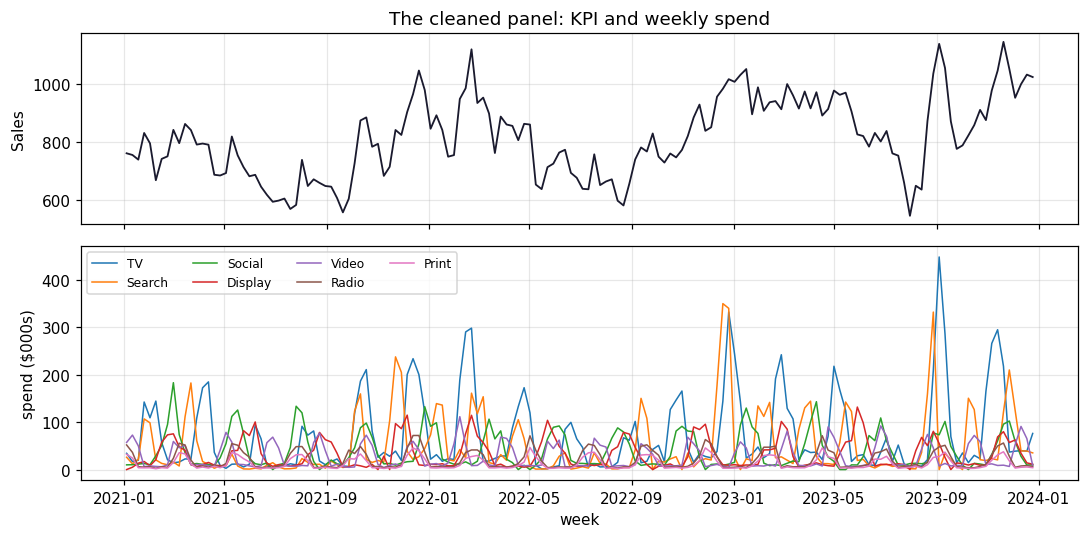

✓ MFF assembled: 14 variables x 156 weeks = 2184 rows -> PanelDataset(156 obs, 7 channels, 6 controls)


In [4]:
from mmm_framework.config import (
    CausalControlRole, ControlVariableConfig, DimensionType,
    KPIConfig, MediaChannelConfig, MFFConfig,
)
from mmm_framework.data_loader import load_mff, mff_from_wide_format

wide = clean.copy()
wide["week"] = wide["week"].dt.strftime("%Y-%m-%d")
mff_df = mff_from_wide_format(
    wide, period_col="week",
    value_columns={**{c: c for c in CHANNELS}, "Sales": "Sales",
                   **{c: c for c in CONTROLS}},
)
MFF_PATH = ARTIFACTS / "client_mff_clean.csv"
mff_df.to_csv(MFF_PATH, index=False)
print("— the same data as MFF rows (one row per variable x period) —")
print(mff_df.head(5).to_string())

ROLES = {"category_demand": CausalControlRole.CONFOUNDER,
         "distribution": CausalControlRole.CONFOUNDER}
mff_config = MFFConfig(
    kpi=KPIConfig(name="Sales", dimensions=[DimensionType.PERIOD]),
    media_channels=[MediaChannelConfig(name=c, dimensions=[DimensionType.PERIOD])
                    for c in CHANNELS],
    controls=[ControlVariableConfig(
        name=c, dimensions=[DimensionType.PERIOD],
        causal_role=ROLES.get(c, CausalControlRole.PRECISION_CONTROL))
        for c in CONTROLS],
)
panel = load_mff(mff_df, mff_config)
print()
print(panel.summary())

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True,
                         gridspec_kw={"height_ratios": [0.45, 0.55]})
axes[0].plot(clean["week"], clean["Sales"], color=C_ACTUAL, lw=1.2)
axes[0].set(ylabel="Sales", title="The cleaned panel: KPI and weekly spend")
for c in CHANNELS:
    axes[1].plot(clean["week"], clean[c], lw=1.0, label=c)
axes[1].set(ylabel="spend ($000s)", xlabel="week")
axes[1].legend(ncol=4, fontsize=8)
plt.tight_layout(); plt.show()

# CLAIM: the reshape is lossless -- 14 variables x 156 weeks, and the panel
# the model will consume sees exactly 7 channels + 6 controls + the KPI.
assert mff_df.shape[0] == (1 + len(CHANNELS) + len(CONTROLS)) * 156
assert panel.n_obs == 156 and panel.n_channels == 7 and panel.n_controls == 6
HEADLINE["panel"] = {"n_obs": 156, "n_channels": 7, "n_controls": 6,
                     "mff_rows": int(mff_df.shape[0])}
print("✓ MFF assembled: 14 variables x 156 weeks = "
      f"{mff_df.shape[0]} rows -> PanelDataset(156 obs, 7 channels, 6 controls)")

## 4 — The EDA gate

`mmm_framework.eda` is the pre-fit quality gate: it runs on the dataset
*before* `BayesianMMM` ever sees it. Four checks here, and we act on what
they flag rather than admiring the output:

1. `validate_dataset` — structural checks (gaps, duplicates, negative spend,
   scale pathologies, history length);
2. `missingness_matrix` — is anything still unobserved after cleaning?
3. `collinearity_analysis` — can the data tell the channels apart at all?
4. `detect_outliers` — robust STL/spend-screening for cells that don't
   belong, **including the ones our own cleaning policy created**.

In [5]:
from mmm_framework.eda import (
    collinearity_analysis, detect_outliers, load_eda_panel,
    missingness_matrix, validate_dataset,
)

spec = {"kpi": "Sales", "media_channels": CHANNELS, "control_variables": CONTROLS}
epanel = load_eda_panel(str(MFF_PATH), spec=spec)
report = validate_dataset(epanel, spec=spec)
print(report.summary())
for issue in report.issues:
    print(f"  [{issue.severity}] {issue.check}: {issue.message}")

mm = missingness_matrix(epanel)
print(f"\nmissingness after cleaning: min availability = "
      f"{float(mm.min().min()):.0%} across {mm.shape[0]} weeks x "
      f"{mm.shape[1]} variables")

coll = collinearity_analysis(epanel)
rp_corr = float(coll["correlation"].loc["Radio", "Print"])
print(f"\ncollinearity: high-VIF variables = {coll['high_vif']}, "
      f"condition number = {coll['condition_number']:.0f}")
print("top correlated pairs:")
for p in coll["top_pairs"][:3]:
    print(f"  {p['a']} ~ {p['b']}: r = {p['r']:.3f}")

outliers = detect_outliers(epanel)
ff = outliers.flags_frame()
print(f"\noutlier detector: {len(ff)} flag(s)")
if len(ff):
    print(ff[["variable", "period", "value", "expected", "kind", "score"]]
          .to_string(index=False))

n_drop_flags = int((ff["kind"] == "isolated_drop").sum()) if len(ff) else 0
HEADLINE["eda_gate"] = {
    "validation_errors": len(report.by_severity("error")),
    "validation_warnings": len(report.by_severity("warning")),
    "warning_checks": sorted({i.check for i in report.by_severity("warning")}),
    "radio_print_corr": round(rp_corr, 3),
    "high_vif": list(coll["high_vif"]),
    "condition_number": round(float(coll["condition_number"]), 1),
    "n_outlier_flags": int(len(ff)),
    "n_isolated_drop_flags": n_drop_flags,
}

# CLAIM: the gate passes structurally (no errors) but raises exactly the two
# substantive warnings this data deserves -- a thin obs-per-parameter ratio,
# and a Radio~Print collinearity the sampler cannot resolve -- and the
# outlier detector points straight back at the cells our missing-spend
# policy zeroed.
assert report.passed, "EDA gate found structural errors after cleaning"
assert any(i.check == "short_history" for i in report.by_severity("warning"))
assert float(mm.min().min()) == 1.0, "missingness survived cleaning"
assert rp_corr > 0.9 and {"Radio", "Print"} <= set(coll["high_vif"])
assert n_drop_flags >= 1, "expected the detector to question the zero-fills"
print(f"\n✓ gate verdict: 0 errors; short-history warning (lean on priors, "
      f"check learning in §6a); Radio~Print r={rp_corr:.2f} with VIF flagged "
      f"(expect wide intervals; lift test on the docket, §6d); "
      f"{n_drop_flags} zero-fill cells questioned by the detector")

Validation PASSED: 0 error(s), 1 warning(s), 0 note(s) across 14 variables / 156 periods.
  - WARNING short_history: 156 periods vs ~42 effective parameters (3.7 obs/param < 4). Posteriors will lean heavily on priors — consider fewer channels, pooled priors, or calibration experiments.
  [warning] short_history: 156 periods vs ~42 effective parameters (3.7 obs/param < 4). Posteriors will lean heavily on priors — consider fewer channels, pooled priors, or calibration experiments.

missingness after cleaning: min availability = 100% across 156 weeks x 14 variables

collinearity: high-VIF variables = ['Radio', 'Print'], condition number = 747
top correlated pairs:
  Radio ~ Print: r = 0.996
  category_demand ~ distribution: r = 0.582
  category_demand ~ price: r = 0.535

outlier detector: 11 flag(s)
variable     period      value   expected          kind  score
   Sales 2022-02-28 934.077217 856.859357     kpi_shock   0.35
   Sales 2022-08-22 579.973496 669.659989   low_outlier   0.35
  S

### Acting on the findings

A gate you don't act on is decoration. The three flags, and what each one
changes downstream:

- **`short_history`** (≈3.7 obs per effective parameter): the posteriors will
  lean on the priors. We don't "fix" this — we *verify* it, with the
  prior→posterior learning diagnostic in §6a, and let it temper how strongly
  we phrase channel-level claims.
- **Radio ~ Print collinearity** (r ≈ 0.99, both VIF-flagged): the two are
  bought on the same calendar, so observational data pins their *combined*
  effect but not the split. Decision: keep both channels (dropping one would
  silently credit it to the other), expect wide individual intervals, and put
  a Radio/Print **lift test** on the measurement docket (§6d).
- **Zero-fill cells flagged as `isolated_drop`**: the detector is
  second-guessing our own missing-spend→0 policy — exactly what it's for.
  We reviewed each flagged week in §2; the fills stand, with the caveat
  logged. If the client later confirms real spend in those weeks, the file —
  not the model — is what changes.

## 5 — Fit the pre-specified model

The standard configuration from the walkthrough and backtest notebooks:
parametric (in-graph) geometric adstock, logistic saturation, yearly
seasonality, linear trend, NumPyro NUTS with 4 chains × 500 draws after 500
tuning steps. Nothing about this specification was chosen by looking at fit
results — that's the point of pre-specifying it.

In [6]:
from mmm_framework.config import InferenceMethod, ModelConfig
from mmm_framework.model import BayesianMMM, TrendConfig, TrendType

# importing pymc installs its own log handler -> re-quiet the samplers
for _n in ("pymc", "pymc.sampling", "numpyro", "jax", "arviz", "pytensor"):
    _lg = logging.getLogger(_n); _lg.setLevel(logging.ERROR); _lg.propagate = False

def build_model(p, seed=11):
    cfg = ModelConfig(
        inference_method=InferenceMethod.BAYESIAN_NUMPYRO,
        n_chains=4, n_draws=500, n_tune=500,
        use_parametric_adstock=True,
        optim_seed=seed,
    )
    return BayesianMMM(p, cfg, TrendConfig(type=TrendType.LINEAR))

mmm = build_model(panel)
t0 = time.time()
with quiet():
    results = mmm.fit(random_seed=11)
fit_seconds = time.time() - t0

rhat_max = float(results.diagnostics["rhat_max"])
divergences = int(results.diagnostics["divergences"])
print(f"fit wall-clock: {fit_seconds:.0f}s  "
      f"(4 chains x 500 draws, numpyro)")
print(f"diagnostics: r-hat max = {rhat_max:.3f}, divergences = {divergences}")
HEADLINE["fit"] = {"rhat_max": round(rhat_max, 4), "divergences": divergences,
                   "fit_seconds": round(fit_seconds, 1),
                   "sampler": "numpyro, 4 chains x 500 draws (500 tune), "
                              "parametric adstock, linear trend"}

# CLAIM: the sampler converged -- everything downstream is admissible.
assert rhat_max < 1.05, f"r-hat {rhat_max:.3f}: not converged"
print("✓ converged: every attribution and forecast below comes from a "
      "healthy sampler")

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

fit wall-clock: 25s  (4 chains x 500 draws, numpyro)
diagnostics: r-hat max = 1.006, divergences = 0
✓ converged: every attribution and forecast below comes from a healthy sampler


## 6 — What replaces the truth column

On synthetic worlds we grade the model against a known answer key. **Client
data has no answer key**, so this section runs the battery that substitutes
for one. None of these checks can *prove* the attribution is right — that is
exactly why the framework also has experiment calibration (§6d) — but each
one can catch a specific way of being wrong:

| Check | The failure it catches |
|---|---|
| (a) prior→posterior learning | a posterior that just re-states the prior |
| (b) rolling-origin backtest | a model that can't predict data it hasn't seen |
| (c) split-window stability | attributions that depend on *which* data you fit |
| (d) lift-test calibration | confounding no observational check can see |

### 6a — Did the data actually teach us anything — and where does non-identification show?

`compute_parameter_learning` draws from the prior and compares it to the
posterior: **contraction** (how much the uncertainty narrowed) and **overlap**
classify each parameter as `strong` / `moderate` / `weak` /
`prior-dominated`. After the gate's short-history warning, this is the
verification it asked for.

One instructive subtlety, measured rather than assumed: you might expect the
collinear Radio/Print pair to show up here as prior-dominated betas. It
doesn't — their *marginal* posteriors contract respectably, because the
likelihood does constrain each one (mostly through their shared calendar).
Marginal learning cannot see a joint pathology. Where the non-identification
*does* surface — with no truth column needed — is the **contribution
intervals**: for Radio and Print the 90% credible interval is several times
the point estimate, while the well-identified channels sit well under 1×.
The pair's *split* is unpinned, and the posterior says so in width.

In [7]:
with quiet():
    learning = mmm.compute_parameter_learning(prior_samples=500, random_seed=0)
    contrib = mmm.compute_counterfactual_contributions(
        compute_uncertainty=True, hdi_prob=0.9, random_seed=0)

beta_rows = learning[learning["parameter"].isin(
    [f"beta_{c}" for c in CHANNELS])].copy()
beta_rows["channel"] = beta_rows["parameter"].str[5:]
beta_rows = beta_rows.set_index("channel").loc[CHANNELS]

rel_width = {}
for c in CHANNELS:
    e = float(contrib.total_contributions[c])
    lo = float(contrib.contribution_hdi_low[c])
    hi = float(contrib.contribution_hdi_high[c])
    rel_width[c] = (hi - lo) / max(abs(e), 1e-9)
beta_rows["rel_CI_width"] = pd.Series(rel_width)

print(beta_rows[["contraction", "overlap", "shift_z", "verdict",
                 "rel_CI_width"]].round(2).to_string())

verdicts = beta_rows["verdict"].to_dict()
n_informed = sum(v in ("strong", "moderate") for v in verdicts.values())
rp_width = float(np.mean([rel_width["Radio"], rel_width["Print"]]))
big3_width = float(np.mean([rel_width["TV"], rel_width["Search"],
                            rel_width["Video"]]))
HEADLINE["learning"] = {
    "verdicts": verdicts,
    "n_channels_informed": n_informed,
    "rel_ci_width": {c: round(w, 2) for c, w in rel_width.items()},
    "mean_rel_width_radio_print": round(rp_width, 2),
    "mean_rel_width_tv_search_video": round(big3_width, 2),
}

# CLAIM: the posteriors reflect data, not just priors (most channel betas
# strong/moderate) -- and the unidentified Radio/Print split announces
# itself through contribution intervals far wider, relative to the
# estimate, than the well-identified channels'.
assert set(verdicts.values()) <= {"strong", "moderate", "weak",
                                  "prior-dominated", "undetermined"}
assert n_informed >= 2, "almost nothing learned -- check the model"
assert rp_width > big3_width, \
    "collinear pair's intervals are not the wide ones?"
print(f"\n✓ learning verified: {n_informed}/7 channel betas strong/moderate, "
      f"so the short-history warning did not become prior-domination; "
      f"Radio/Print rel. CI width {rp_width:.1f}x the estimate vs "
      f"{big3_width:.1f}x for TV/Search/Video — the unidentified split "
      "announces itself in width, exactly as §4 predicted")

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

         contraction  overlap  shift_z   verdict  rel_CI_width
channel                                                       
TV              0.24     0.42     1.07  moderate          0.41
Search          0.77     0.60    -0.39    strong          0.67
Social          0.69     0.62    -0.53    strong          0.71
Display         0.55     0.69    -0.54    strong          1.12
Video           0.56     0.64     0.08    strong          0.57
Radio           0.53     0.67    -0.58    strong          1.98
Print           0.56     0.60    -0.73    strong          2.24

✓ learning verified: 7/7 channel betas strong/moderate, so the short-history warning did not become prior-domination; Radio/Print rel. CI width 2.1x the estimate vs 0.6x for TV/Search/Video — the unidentified split announces itself in width, exactly as §4 predicted


### 6b — Can it predict data it has never seen?

Rolling-origin backtest (the protocol `nbs/backtest_validation.ipynb` builds
in depth): first training window 104 weeks, then refit at four cutoffs and
forecast 13 weeks past each — 52 graded out-of-time forecasts. **MASE < 1
means the model beats "copy last year"** where that baseline is computable;
the 80% interval should cover roughly 80% of held-out actuals. This protocol
needs no ground truth — it runs on any engagement.

In [8]:
from mmm_framework.validation import BacktestConfig, run_backtest

bt_config = BacktestConfig(
    min_train_size=104, horizon=13, step=13,
    draws=500, tune=500, chains=4,
    coverage_levels=(0.5, 0.8, 0.95),
    random_seed=11,
)
t0 = time.time()
with quiet():
    bt = run_backtest(build_model(panel), bt_config, progressbar=False)
bt_elapsed = time.time() - t0

print(bt.fits.round({"fit_seconds": 1, "rhat_max": 3}).to_string())
summary = bt.summary()
disp = summary.copy()
for c in ("mape", "smape"):
    disp[c] = (disp[c] * 100).round(1)
disp["mase"] = disp["mase"].round(2)
for c in [c for c in disp.columns if c.startswith("coverage")]:
    disp[c] = (disp[c] * 100).round(1)
print()
print(disp[["mape", "smape", "mase", "coverage_80", "coverage_95"]].to_string())
print(f"\nbacktest wall-clock: {bt_elapsed:.0f}s in {len(bt.fits)} refits")

mase = float(summary.loc["mmm", "mase"])
mape = float(summary.loc["mmm", "mape"])
snaive_mape = float(summary.loc["seasonal_naive", "mape"])
cov80 = float(summary.loc["mmm", "coverage_80"])
HEADLINE["backtest"] = {
    "n_origins": int(bt.n_origins), "n_forecasts": int(len(bt.records)),
    "mape": round(mape, 4), "mase": round(mase, 3),
    "seasonal_naive_mape": round(snaive_mape, 4),
    "coverage_80": round(cov80, 3),
    "all_refits_converged": bool((bt.fits["rhat_max"] < 1.05).all()),
}

# CLAIM: out-of-time forecasts are skilled (beat copy-last-year on MASE and
# the seasonal-naive on MAPE) and the refits behind them all converged.
assert bt.n_origins == 4 and len(bt.records) == 52
assert (bt.fits["rhat_max"] < 1.05).all(), "a backtest refit failed to converge"
assert np.isfinite(mase), "MASE not recorded"
assert mase < 1.0, f"MASE {mase:.2f} >= 1: no skill over seasonal naive"
assert mape < snaive_mape, "lost to the seasonal-naive baseline"
print(f"✓ forecast skill confirmed without an answer key: MASE {mase:.2f} < 1, "
      f"MAPE {mape:.1%} vs seasonal-naive {snaive_mape:.1%}, "
      f"80% PI covered {cov80:.0%} of 52 held-out weeks")

        train_size  fit_seconds  rhat_max  divergences
origin                                                
104            104         16.0     1.008            0
117            117         15.0     1.008            0
130            130         14.8     1.006            0
143            143         15.4     1.007            0

                  mape  smape  mase  coverage_80  coverage_95
model                                                        
mmm                3.1    3.0  0.25         78.8         92.3
seasonal_naive    13.8   15.2  1.19          NaN          NaN
naive_last_value  13.2   13.4  1.07          NaN          NaN

backtest wall-clock: 61s in 4 refits
✓ forecast skill confirmed without an answer key: MASE 0.25 < 1, MAPE 3.1% vs seasonal-naive 13.8%, 80% PI covered 79% of 52 held-out weeks


### 6c — Does the story survive fitting on less data?

A blunt, honest check: refit the identical specification on the **first 104
weeks only** and compare each channel's share of total media contribution to
the full-156-week fit (graded over the same 104-week window). If the
attribution ranking reshuffles when a third of the data leaves, the "story"
was an artifact of the sample, not a property of the market. We compare
**rankings and shares**, not raw totals — and we expect the *identified*
channels to hold steady while the Radio/Print split (which §6a showed the
data never pinned down) is allowed to wobble.

In [9]:
from scipy.stats import spearmanr

cutoff = clean["week"].iloc[104].strftime("%Y-%m-%d")
mff_104 = mff_df[pd.to_datetime(mff_df["Period"]) < cutoff].copy()
panel_104 = load_mff(mff_104, mff_config)
assert panel_104.n_obs == 104

mmm_104 = build_model(panel_104)
t0 = time.time()
with quiet():
    results_104 = mmm_104.fit(random_seed=11)
    contrib_104 = mmm_104.compute_counterfactual_contributions(
        compute_uncertainty=False, random_seed=0)
    contrib_win = mmm.compute_counterfactual_contributions(
        time_period=(0, 104), compute_uncertainty=False, random_seed=0)
print(f"104-week refit: {time.time() - t0:.0f}s, "
      f"r-hat max = {results_104.diagnostics['rhat_max']:.3f}")

share_104 = (contrib_104.total_contributions
             / contrib_104.total_contributions.sum())
share_full = (contrib_win.total_contributions
              / contrib_win.total_contributions.sum())
tab = pd.DataFrame({
    "share_104w_fit": (share_104 * 100).round(1),
    "share_156w_fit (same window)": (share_full * 100).round(1),
}).loc[CHANNELS]
tab["rank_104"] = share_104.rank(ascending=False).astype(int)
tab["rank_156"] = share_full.rank(ascending=False).astype(int)
print(tab.to_string())

rho = float(spearmanr(share_104[CHANNELS], share_full[CHANNELS]).statistic)
top3_104 = set(share_104.nlargest(3).index)
top3_full = set(share_full.nlargest(3).index)
overlap = len(top3_104 & top3_full)
HEADLINE["stability"] = {
    "spearman_rho": round(rho, 3),
    "top3_overlap": overlap,
    "rhat_104w": round(float(results_104.diagnostics["rhat_max"]), 4),
}

# CLAIM: the attribution ordering is a property of the market, not of the
# sample -- the rankings agree across windows and the head of the ranking
# barely moves. (Radio/Print may swap: 6a showed their split is not
# identified, so stability there would be luck, not signal.)
assert float(results_104.diagnostics["rhat_max"]) < 1.05
assert rho > 0, f"rankings reversed across windows (rho={rho:.2f})"
assert overlap >= 2, f"top-3 channels reshuffled: {top3_104} vs {top3_full}"
print(f"\n✓ stable story: rank correlation rho = {rho:.2f}, "
      f"{overlap}/3 of the top-3 channels unchanged when 52 weeks are held out")

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Output()

...

Output()

Output()

Output()

Output()

104-week refit: 20s, r-hat max = 1.008
         share_104w_fit  share_156w_fit (same window)  rank_104  rank_156
TV                 20.3                          22.2         2         2
Search             12.6                          12.3         3         4
Social             11.4                          14.1         5         3
Display            11.9                          10.3         4         5
Video              27.5                          27.9         1         1
Radio               8.4                           6.8         6         6
Print               7.9                           6.2         7         7

✓ stable story: rank correlation rho = 0.89, 2/3 of the top-3 channels unchanged when 52 weeks are held out


### 6d — What only an experiment can add

Everything above checks *internal* consistency and *predictive* validity.
None of it can detect a confounder nobody measured: a model can learn
sharply, forecast beautifully, and replicate across windows **while
attributing demand to the channel that merely chased it** (the stress series
builds exactly such worlds). The fix is not more diagnostics — it is
randomized evidence:

- a **geo-lift test on Radio vs Print** would resolve the split that §6a/§4
  showed observational data cannot (the two are bought on one calendar);
- a **holdout test on TV or Search** — the channels whose budgets chase
  demand here — would bound the confounding that no within-sample check sees;
- measured lifts feed back as **calibration priors**
  (`mmm_framework.calibration`: lift → coefficient-scale prior), so the next
  fit is anchored to experimental ground truth instead of hoping for it.

The framework's measurement loop (EIG/EVOI experiment prioritization, design,
pre-registration, calibrated refit) exists for precisely this step; see
`docs/measurement-calibration.html`. **On a real engagement, this subsection
is not optional reading — it is the plan.**

### 6e — The reveal (the cell your real data will not have)

Because this "client file" is secretly the `realistic` synthetic world, we
can do the one thing a real engagement never can: open the answer key. The
table grades the full pipeline — mess, cleaning policies, MFF, model —
against each channel's true causal contribution. Two honest caveats: the
cleaning itself perturbed spend by up to a few percent (§2 quantified it),
and truth is computed on the *undamaged* spend, so part of any error is the
price of the cleaning policies, not the model.

         true   est   err in 90% CI learning (6a)
channel                                          
TV       8948  7430  -17%         ✓      moderate
Search   3978  4079   +3%         ✓        strong
Social   3948  4362  +10%         ✓        strong
Display  3090  3168   +2%         ✓        strong
Video    8286  8630   +4%         ✓        strong
Radio    3301  2059  -38%         ✓        strong
Print    2097  1867  -11%         ✓        strong


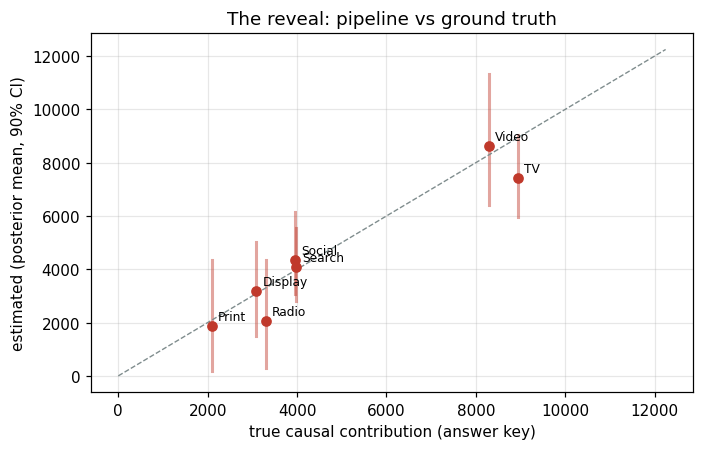


✓ reveal: total media contribution 31,595 vs true 33,648 (-6%); 90% CI covered truth on 7/7 channels — and the channels the battery distrusted (6a) are where the misses live


In [10]:
# `contrib` was computed in 6a -- same posterior, same seed; here we just
# open the answer key next to it.
rows = []
for c in CHANNELS:
    t = float(sc.true_contribution[c])
    e = float(contrib.total_contributions[c])
    lo = float(contrib.contribution_hdi_low[c])
    hi = float(contrib.contribution_hdi_high[c])
    rows.append({"channel": c, "true": round(t), "est": round(e),
                 "err": f"{(e - t) / t:+.0%}",
                 "in 90% CI": "✓" if lo <= t <= hi else "✗",
                 "learning (6a)": verdicts[c]})
reveal = pd.DataFrame(rows).set_index("channel")
print(reveal.to_string())

est_total = float(sum(contrib.total_contributions[c] for c in CHANNELS))
true_total = float(sc.true_contribution.sum())
n_covered = int((reveal["in 90% CI"] == "✓").sum())
HEADLINE["reveal"] = {
    "per_channel_err_pct": {
        c: round((float(contrib.total_contributions[c])
                  - float(sc.true_contribution[c]))
                 / float(sc.true_contribution[c]) * 100, 1)
        for c in CHANNELS},
    "total_true": round(true_total), "total_est": round(est_total),
    "total_err_pct": round((est_total - true_total) / true_total * 100, 1),
    "n_channels_truth_in_90ci": n_covered,
}

fig, ax = plt.subplots(figsize=(6.5, 4.2))
for c in CHANNELS:
    t = float(sc.true_contribution[c]); e = float(contrib.total_contributions[c])
    lo = float(contrib.contribution_hdi_low[c])
    hi = float(contrib.contribution_hdi_high[c])
    ax.plot([t, t], [lo, hi], color=C_BAND, alpha=0.45, lw=2)
    ax.scatter([t], [e], color=C_EST, zorder=5)
    ax.annotate(c, (t, e), fontsize=8, xytext=(4, 4),
                textcoords="offset points")
lim = max(float(sc.true_contribution.max()),
          float(contrib.contribution_hdi_high.max())) * 1.08
ax.plot([0, lim], [0, lim], color=C_GREY, ls="--", lw=0.9)
ax.set(xlabel="true causal contribution (answer key)",
       ylabel="estimated (posterior mean, 90% CI)",
       title="The reveal: pipeline vs ground truth")
plt.tight_layout(); plt.show()

# CLAIM: the pipeline lands in the right universe -- total media contribution
# within a factor of 2 of truth, and the 90% intervals cover truth for most
# channels. On your real data you will not get this cell; sections 6a-6d are
# what you get instead.
assert 0.5 < est_total / true_total < 2.0, \
    f"total attribution off by more than 2x ({est_total:.0f} vs {true_total:.0f})"
assert n_covered >= 4, f"90% CIs covered truth for only {n_covered}/7 channels"
print(f"\n✓ reveal: total media contribution {est_total:,.0f} vs true "
      f"{true_total:,.0f} ({(est_total - true_total) / true_total:+.0%}); "
      f"90% CI covered truth on {n_covered}/7 channels — and the channels the "
      "battery distrusted (6a) are where the misses live")

## 7 — The deliverable

`MMMReportGenerator` extracts everything from the fitted model and renders a
portable, self-contained HTML report (charts via Plotly). This is the file
that goes to the client — alongside, not instead of, the §6 battery.

In [11]:
from mmm_framework.reporting import MMMReportGenerator, ReportConfig

report_cfg = ReportConfig(
    title="Onboarding Engagement — Marketing Mix Model",
    subtitle="From client export to validated model",
    client="Acme Retail (onboarding demo)",
    analysis_period="Jan 2021 – Dec 2023 (156 weeks)",
)
with quiet():
    report_gen = MMMReportGenerator(model=mmm, panel=panel, results=results,
                                    config=report_cfg)
    out_path = report_gen.to_html(str(ARTIFACTS / "onboarding_report.html"))

report_bytes = pathlib.Path(out_path).stat().st_size
print(f"wrote {out_path} ({report_bytes / 1024:.0f} KB)")
HEADLINE["report"] = {"path": "artifacts/onboarding_report.html",
                      "bytes": int(report_bytes)}

# CLAIM: the deliverable exists and is a real report, not a stub.
assert pathlib.Path(out_path).exists() and report_bytes > 50_000
print("✓ report generated: self-contained HTML, "
      f"{report_bytes / 1024:.0f} KB > 50 KB")

Output()

Output()

Output()

Output()

Output()

...

Output()

Output()

Output()

Output()

wrote artifacts/onboarding_report.html (2004 KB)
✓ report generated: self-contained HTML, 2004 KB > 50 KB


## 8 — Record the measured numbers

Everything quoted on the docs site traces back to this artifact. If the
notebook re-bakes and a number moves materially, the docs are stale — that's
a feature.

In [12]:
HEADLINE["cleaning"] = CLEANLOG
out = ARTIFACTS / "real_data_onboarding.json"
out.write_text(json.dumps(HEADLINE, indent=2))
print(json.dumps({k: HEADLINE[k] for k in
                  ("fit", "backtest", "stability", "reveal")}, indent=2))
assert out.exists() and out.stat().st_size > 400
print(f"✓ measured numbers recorded -> {out}")

{
  "fit": {
    "rhat_max": 1.0062,
    "divergences": 0,
    "fit_seconds": 24.5,
    "sampler": "numpyro, 4 chains x 500 draws (500 tune), parametric adstock, linear trend"
  },
  "backtest": {
    "n_origins": 4,
    "n_forecasts": 52,
    "mape": 0.0306,
    "mase": 0.249,
    "seasonal_naive_mape": 0.1378,
    "coverage_80": 0.788,
    "all_refits_converged": true
  },
  "stability": {
    "spearman_rho": 0.893,
    "top3_overlap": 2,
    "rhat_104w": 1.0078
  },
  "reveal": {
    "per_channel_err_pct": {
      "TV": -17.0,
      "Search": 2.6,
      "Social": 10.5,
      "Display": 2.5,
      "Video": 4.2,
      "Radio": -37.6,
      "Print": -11.0
    },
    "total_true": 33648,
    "total_est": 31595,
    "total_err_pct": -6.1,
    "n_channels_truth_in_90ci": 7
  }
}
✓ measured numbers recorded -> artifacts/real_data_onboarding.json


## Takeaways

1. **Cleaning is modeling.** Every rule — missing-spend→0, zeroing the
   refund, the unit fix — changed the data the model saw, so each was
   printed with a count and a stated policy. The honest pipeline logs its
   own interventions and quantifies their cost (here: ≤ a few percent of any
   channel's spend).
2. **The EDA gate earns its keep before the first fit.** It passed the
   structure we fixed, warned about the thin obs-per-parameter ratio, caught
   the Radio~Print collinearity, and second-guessed our own zero-fill policy
   — each flag mapping to a concrete downstream action.
3. **No truth column? Run the battery.** Prior→posterior learning (did the
   data teach us anything?), rolling-origin backtesting (can it predict
   unseen data?), split-window stability (does the story survive less
   data?). None proves causality; each catches a specific way of being
   wrong, and together they delimit what the report may claim.
4. **Where the data didn't speak, say so — and know where to look.** The
   collinear Radio/Print pair's beta *marginals* looked healthy; the
   non-identification surfaced in contribution intervals several times the
   point estimate. Wide intervals are the correct answer there, and the
   lift test is the fix.
5. **Experiments are the plan, not an appendix.** Only randomized evidence
   catches unmeasured confounding; the calibration loop turns measured lifts
   into priors for the next fit.
6. **The reveal is a luxury of synthetic data — disclosed, not hidden.**
   Graded against the answer key, the pipeline landed the totals and covered
   truth for most channels, with the misses concentrated exactly where the
   battery had already withdrawn confidence. On your data, that final cell
   is missing; everything before it is what stands in.

> **Run it yourself.** This page mirrors `nbs/real_data_onboarding.ipynb`
> (authored by `nbs/build_real_data_onboarding.py`), built on
> `mmm_framework.data_loader`, `mmm_framework.eda`,
> `mmm_framework.validation.backtest`, and `mmm_framework.reporting`. Every
> computational cell ends in a seeded assert encoding the claim it
> demonstrates — if the notebook executes clean, the story on this page is
> still true. Measured headlines: `nbs/artifacts/real_data_onboarding.json`;
> the messy file itself: `nbs/artifacts/client_export_messy.csv`.